# Testing the draft grouped box plot (`team/new_graphics/new_graphics_demos/boxplot.py`)

This notebook exercises `make_boxplot()`, the draft implementation of the new
grouped box plot type. It is **not** wired into `.plot()` yet — this is for
visually checking the draft before integration.

`make_boxplot()` reuses the same "category plus optional `hue`" design as the
draft `make_violin()` in `team/new_graphics/violin.py`: a second categorical
column dodges each category's box into one box per hue level, colored by
level instead of by category. Unlike the violin's inner boxplot (a neutral
pale box drawn *inside* a colored density shape), here the box itself carries
the Okabe-Ito color, since there's no density shape to share it with.

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then Run All.

**What to look for in every plot:**
- One box per category (or per category × hue level): edges at the first and
  third quartiles, a black median line, whiskers to the most extreme value
  within 1.5×IQR, and individual fliers beyond that
- Thin black outline on every box, whisker, and cap
- x-axis always reads "Category", y-axis always reads "Value"
- With `hue`: boxes for a category are dodged side by side and colored by
  hue level (Okabe-Ito palette); a legend titled by `hue_name` appears in the
  top right
- Without `hue`: one box per category, single color, no legend

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/, the
# same folder as the draft boxplot.py module.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo (not an older
# installed copy in site-packages), and `from boxplot import ...` find the
# draft module in this same folder.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(Path.cwd()))

# The draft helper and its per-plot-type constants
from boxplot import make_boxplot, BOXPLOT_WIDTH_RATIO

# Apply the global style file (Okabe-Ito cycle, grid, spines, fonts).
# Not yet wired into the package, so we apply it by hand here.
STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(STYLE_PATH)

rng = np.random.default_rng(7)
print(f"BOXPLOT_WIDTH_RATIO = {BOXPLOT_WIDTH_RATIO}")

BOXPLOT_WIDTH_RATIO = 0.7


## 1. Reproduce the same scenario as the violin prototype

Same four categories (Group A–D) and "No"/"Yes" subgroups as the violin demo,
so the two draft plot types can be compared side by side on identical data.
Each subgroup gets its own dodged box colored by the Okabe-Ito cycle (sky
blue / orange). A legend titled "Subgroup" appears in the top right.

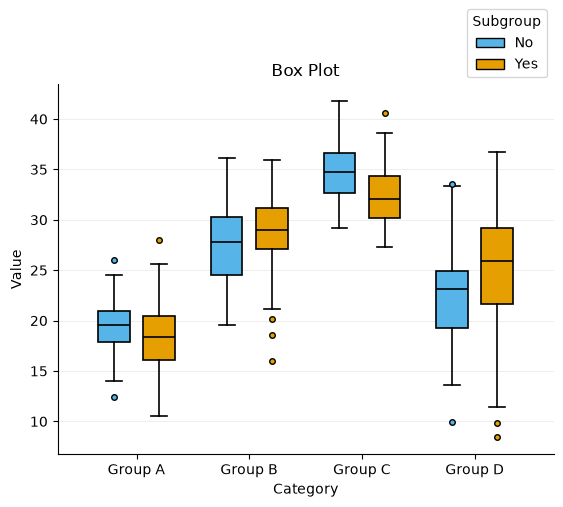

In [2]:
group_specs = {
    "Group A": {"No": (20, 3), "Yes": (19, 4)},
    "Group B": {"No": (28, 4), "Yes": (29, 4)},
    "Group C": {"No": (35, 3), "Yes": (33, 3)},
    "Group D": {"No": (24, 5), "Yes": (25, 6)},
}
n_per_cell = 80
categories, subgroups, values = [], [], []
for group, subs in group_specs.items():
    for sub, (mean, sd) in subs.items():
        categories.extend([group] * n_per_cell)
        subgroups.extend([sub] * n_per_cell)
        values.extend(rng.normal(mean, sd, n_per_cell))

ax = plt.gca()
make_boxplot(categories, values, ax, hue=subgroups, hue_name="Subgroup")
plt.show()

## 2. Options: no `hue`

Without `hue`, one box is drawn per category in a single color (the first
Okabe-Ito hue).

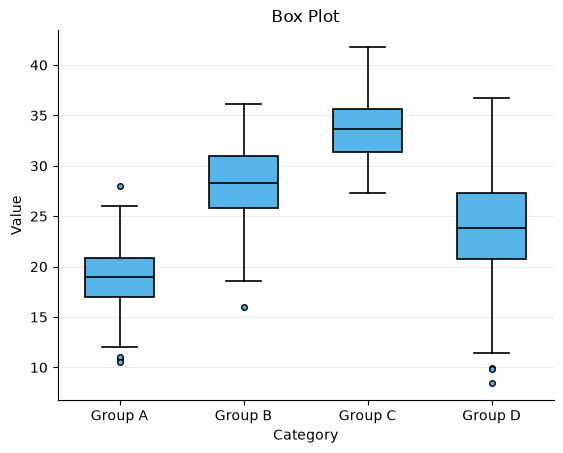

In [3]:
# No hue -- one box per category, single color, no legend
ax = plt.gca()
make_boxplot(categories, values, ax)
plt.show()

## 3. Overlay behavior — readability warning

Per CLAUDE.md's overlay policy, two box plots on the same axes fall into the
"readability warning" category (like two violin plots, two tile plots, or
two 2D histograms): the plot still draws, but a warning prints below it
because the boxes are hard to tell apart.

Like the violin plot, a box's x-position comes from the *data's own category
labels*, not from a per-axes call counter — so a second call whose data
shares category labels with the first lands its box in the exact same lane
as the first call's. Below, two cohorts share category labels but have
different distributions; with no `hue` to dodge them apart, each call draws
one box per category, so the second cohort's box lands directly on the
first's and the two boxes overlap into a confusing shape — exactly what the
warning is flagging.

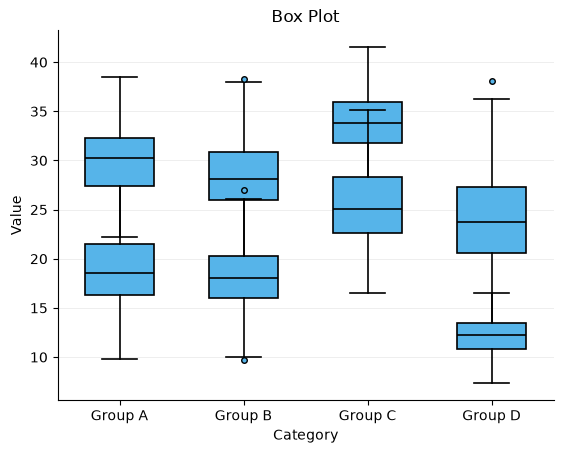

In [4]:
# Two cohorts that share category labels but have different
# distributions. With no hue to dodge them apart, each call draws exactly
# one box per category, so the second cohort's box lands right on top of
# the first's.
cohort1_specs = {"Group A": (19, 4), "Group B": (28, 4), "Group C": (34, 3), "Group D": (24, 5)}
cohort2_specs = {"Group A": (30, 3), "Group B": (18, 3), "Group C": (26, 4), "Group D": (12, 2)}

categories1, values1 = [], []
for group, (mean, sd) in cohort1_specs.items():
    categories1.extend([group] * (2 * n_per_cell))
    values1.extend(rng.normal(mean, sd, 2 * n_per_cell))

categories2, values2 = [], []
for group, (mean, sd) in cohort2_specs.items():
    categories2.extend([group] * (2 * n_per_cell))
    values2.extend(rng.normal(mean, sd, 2 * n_per_cell))

ax = plt.gca()
make_boxplot(categories1, values1, ax)
make_boxplot(categories2, values2, ax)  # triggers the warning
plt.show()

## 4. With real symbulate simulation data

Same shape of data, but the category and subgroup labels come from
`BoxModel` simulations instead of hand-written lists, and the value comes
from an independent `Normal` draw — exactly the kind of grouped output a
future `.plot(type="boxplot")` call would receive.

Caveat while testing today: creating `RVResults` currently calls
`init_color()`, which resets the color cycle to tab10 (removed in Phase 2),
so we re-apply the style *after* simulating.

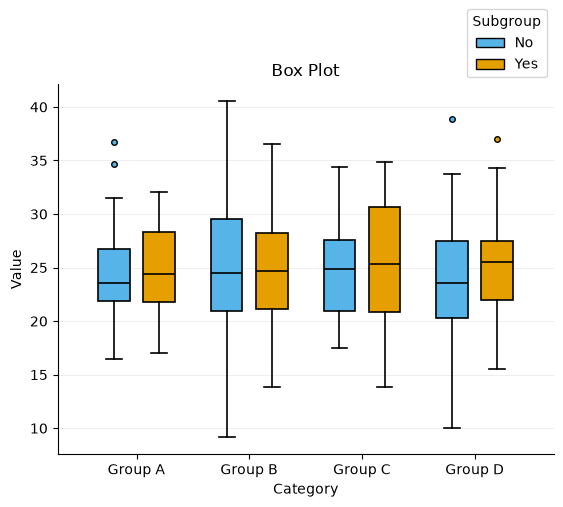

In [5]:
from symbulate import RV, BoxModel, Normal

n = 300
category_sims = RV(BoxModel(["Group A", "Group B", "Group C", "Group D"])).sim(n)
subgroup_sims = RV(BoxModel(["Yes", "No"])).sim(n)
value_sims = RV(Normal(25, 5)).sim(n)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_boxplot(
    np.asarray(category_sims.results),
    np.asarray(value_sims.results),
    ax,
    hue=np.asarray(subgroup_sims.results),
    hue_name="Subgroup",
)
plt.show()

## Verification checklist

- [ ] Section 1 matches the violin prototype's data: 4 categories, 2 dodged
      boxes each, Okabe-Ito colors, legend titled "Subgroup" in the top right
- [ ] Every box has a thin black outline, black median line, whiskers, and
      caps; fliers beyond 1.5×IQR are drawn as individual points
- [ ] x-axis always reads "Category", y-axis always reads "Value"
- [ ] Title always reads "Box Plot", with or without `hue`
- [ ] Without `hue`: one box per category, single color, no legend
- [ ] A second box plot on the same axes still draws, but prints the
      readability warning below it
- [ ] Works on real `.sim()` output (`BoxModel` categories/subgroups,
      `Normal` values), not just hand-written lists